## Brazilian E-Commerce Public Dataset by Olist

Problem statement :- Can we predict how many days it will take to deliver an order?

ok so now this is a regressioon problem :- we have to predict on thing delivery time 

now I will understand all the tables in a database so load them and display the features/columns 

In [1]:
import numpy as np 

In [2]:
import pandas as pd

In [ ]:
customer_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_customers_dataset.csv")
print("customer table :- " ,customer_table.columns) 

geolocation_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_geolocation_dataset.csv")
print("geolocation table :- " ,geolocation_table.columns)

order_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_orders_dataset.csv")
print("order table :- " ,order_table.columns)

order_items_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_order_items_dataset.csv")
print("order items table :- " ,order_items_table.columns)

order_reviews_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_order_reviews_dataset.csv")
print("order reviews table :- " ,order_reviews_table.columns)

product_category_name_translation_table = pd.read_csv("F:\hub_brocker_it\dataset\product_category_name_translation.csv")
print("product category name translation table :- " ,product_category_name_translation_table.columns)

product_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_products_dataset.csv")
print("product table :- " ,product_table.columns)

seller_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_sellers_dataset.csv")
print("seller table :- " ,seller_table.columns)



customer table :-  Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
geolocation table :-  Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
order table :-  Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
order items table :-  Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
order reviews table :-  Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
product category name translation table :-  Index([

In [23]:
order_payment_table = pd.read_csv("F:\hub_brocker_it\dataset\olist_order_payments_dataset.csv")
print("order payment table :- " ,order_payment_table.columns)

order payment table :-  Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')


### now we will now analysis of every table 

In [7]:
print("info\n\n" , customer_table.info())
print("describe \n\n" , customer_table.describe())
print("null values \n\n" , customer_table.isnull().sum())
print("unique values \n\n" , customer_table.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
info

 None
describe 

        customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
null values 

 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state   

In [8]:
print("info\n\n" , order_table.info())
print("describe \n\n" , order_table.describe())
print("null values \n\n" , order_table.isnull().sum())
print("unique values \n\n" , order_table.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
info

 None
describe 

                                 order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top 

df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [11]:
required_dataset = order_table.merge(customer_table , on = "customer_id", how = "left")
required_dataset


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


df = df.merge(
    order_items,
    on="order_id",
    how="left"
)

In [12]:
required_dataset = required_dataset.merge(order_items_table , on = "order_id", how = "left")
required_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


df = df.merge(
    products,
    on="product_id",
    how="left"
)

In [15]:
required_dataset = required_dataset.merge(product_table , on = "product_id" , how = "left")
required_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,174.90,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,205.99,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,179.99,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,179.99,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0


In [19]:
order_items_table["order_id"].duplicated().sum()

np.int64(13984)

## aggregate the order items 

order_items_agg = (
    order_items
    .groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
    .reset_index()
)

In [27]:
order_items_agg = (
    order_items_table.groupby("order_id").agg(
        total_order_value = pd.NamedAgg(column = "price" , aggfunc = "sum"),
        total_order_items = pd.NamedAgg(column = "order_item_id" , aggfunc = "count"),
        total_freight_value = pd.NamedAgg(column = "freight_value" , aggfunc = "sum")
    )
    .reset_index()
)


In [28]:
order_items_agg

,order_id,total_order_value,total_order_items,total_freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,1,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,1,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,1,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,1,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,1,18.14
...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,1,43.41
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,1,36.53
98663,fffce4705a9662cd70adb13d4a31832d,99.90,1,16.95
98664,fffe18544ffabc95dfada21779c9644f,55.99,1,8.72


In [25]:
order_payment_table["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [30]:
order_payment_table["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

payments_agg = (
    payments
    .groupby("order_id")
    .agg(
        total_payment=("payment_value", "sum"),
        max_installments=("payment_installments", "max"),
        payment_type=("payment_type", "first")
    )
    .reset_index()
)

In [29]:
payment_agg = (
    order_payment_table.groupby("order_id").agg(
        total_payment_value = pd.NamedAgg(column = "payment_value" , aggfunc = "sum"),
        total_payment_installments = pd.NamedAgg(column = "payment_installments" , aggfunc = "sum"),
        total_payment_type = pd.NamedAgg(column = "payment_type" , aggfunc = "count")
    )
    .reset_index()
)

In [31]:
payment_agg

,order_id,total_payment_value,total_payment_installments,total_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1
...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40,1,1
99436,fffcd46ef2263f404302a634eb57f7eb,386.53,1,1
99437,fffce4705a9662cd70adb13d4a31832d,116.85,3,1
99438,fffe18544ffabc95dfada21779c9644f,64.71,3,1


Refactoring the hole flow 

In [32]:
required_dataset = order_table.merge(customer_table , on = "customer_id", how = "left")
required_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [34]:
order_items_products = order_items_table.merge(
    product_table,
    on="product_id",
    how="left"
)

In [35]:
order_items_agg = (
    order_items_table.groupby("order_id").agg(
        total_order_value = pd.NamedAgg(column = "price" , aggfunc = "sum"),
        total_order_items = pd.NamedAgg(column = "order_item_id" , aggfunc = "count"),
        total_freight_value = pd.NamedAgg(column = "freight_value" , aggfunc = "sum")
    )
    .reset_index()
)

In [36]:
payment_agg = (
    order_payment_table.groupby("order_id").agg(
        total_payment_value = pd.NamedAgg(column = "payment_value" , aggfunc = "sum"),
        total_payment_installments = pd.NamedAgg(column = "payment_installments" , aggfunc = "sum"),
        total_payment_type = pd.NamedAgg(column = "payment_type" , aggfunc = "count")
    )
    .reset_index()
)

df = df.merge(order_items_agg, on="order_id", how="left")

df = df.merge(payments_agg, on="order_id", how="left")

In [37]:
required_dataset = required_dataset.merge(order_items_agg , on = "order_id", how = "left")

In [38]:
required_dataset = required_dataset.merge(payment_agg , on = "order_id", how = "left")

In [39]:
required_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_order_value,total_order_items,total_freight_value,total_payment_value,total_payment_installments,total_payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,1.0,8.72,38.71,3.0,3.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,1.0,22.76,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,1.0,19.22,179.12,3.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,1.0,27.20,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,1.0,8.72,28.62,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,72.00,1.0,13.08,85.08,3.0,1.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,174.90,1.0,20.10,195.00,3.0,1.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,205.99,1.0,65.02,271.01,5.0,1.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,359.98,2.0,81.18,441.16,4.0,1.0


In [40]:
print(required_dataset.shape)

(99441, 18)


In [41]:
print("Unique orders:", required_dataset["order_id"].nunique())

print("Duplicate orders:", required_dataset["order_id"].duplicated().sum())

Unique orders: 99441
Duplicate orders: 0


## upto this was just the table aggregation to get the desired dataset 

## Now we will do data preprocessing

In [ ]:
df["delivery_time"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

In [49]:
required_dataset["delivery_time"] = (
    required_dataset["order_delivered_customer_date"].to_datetime() -
    required_dataset["order_purchase_timestamp"].to_datetime()

).dt.days

AttributeError: 'Series' object has no attribute 'to_datetime'

In [82]:
required_dataset["delivery_time"] = (
    pd.to_datetime(required_dataset["order_delivered_customer_date"]) -
    pd.to_datetime(required_dataset["order_purchase_timestamp"])
).dt.days

In [83]:
required_dataset["delivery_time"].isnull().sum()

np.int64(2965)

In [42]:
required_dataset.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_order_value                 775
total_order_items                 775
total_freight_value               775
total_payment_value                 1
total_payment_installments          1
total_payment_type                  1
dtype: int64

In [44]:
required_dataset.duplicated().sum()

np.int64(0)

In [45]:
required_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_unique_id             99441 non-null  object 
 9   customer_zip_code_prefix       99441 non-null  int64  
 10  customer_city                  99441 non-null  object 
 11  customer_state                 99441 non-null  object 
 12  total_order_value              98666 non-null 

In [51]:
required_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_order_value,total_order_items,total_freight_value,total_payment_value,total_payment_installments,total_payment_type,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,1.0,8.72,38.71,3.0,3.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,1.0,22.76,141.46,1.0,1.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,1.0,19.22,179.12,3.0,1.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,1.0,27.20,72.20,1.0,1.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,1.0,8.72,28.62,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,72.00,1.0,13.08,85.08,3.0,1.0,8.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,174.90,1.0,20.10,195.00,3.0,1.0,22.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,205.99,1.0,65.02,271.01,5.0,1.0,24.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,359.98,2.0,81.18,441.16,4.0,1.0,17.0


In [52]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    required_dataset[col] = pd.to_datetime(required_dataset[col])

In [59]:
required_dataset["purchase_year"] = required_dataset["order_purchase_timestamp"].dt.year
required_dataset["purchase_month"] = required_dataset["order_purchase_timestamp"].dt.month
required_dataset["purchase_day"] = required_dataset["order_purchase_timestamp"].dt.day
required_dataset["purchase_hour"] = required_dataset["order_purchase_timestamp"].dt.hour
required_dataset["purchase_weekday"] = required_dataset["order_purchase_timestamp"].dt.dayofweek

In [120]:
drop_cols = [
    "order_id",
    "customer_id",
    "customer_unique_id",

    "delivery_time",

    "order_delivered_customer_date",

    "order_delivered_carrier_date", 
    "customer_city"
]

In [ ]:
X = required_dataset.drop(columns=drop_cols)

In [61]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_status                   99441 non-null  object        
 1   order_purchase_timestamp       99441 non-null  datetime64[ns]
 2   order_approved_at              99281 non-null  datetime64[ns]
 3   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 4   customer_zip_code_prefix       99441 non-null  int64         
 5   customer_city                  99441 non-null  object        
 6   customer_state                 99441 non-null  object        
 7   total_order_value              98666 non-null  float64       
 8   total_order_items              98666 non-null  float64       
 9   total_freight_value            98666 non-null  float64       
 10  total_payment_value            99440 non-null  float64       
 11  total_payment_i

In [144]:
num_cols = x.select_dtypes(include=["int64","float64"]).columns

cat_cols = X1.select_dtypes(include=["object"]).columns

In [63]:
X = X.drop(columns=[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date"
])

In [99]:
X1

,order_status,customer_zip_code_prefix,customer_city,customer_state,total_order_value,total_order_items,total_freight_value,total_payment_value,total_payment_installments,total_payment_type,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_weekday,delivery_time
0,delivered,3149,sao paulo,SP,29.99,1.0,8.72,38.71,3.0,3.0,2017,10,2,10,0,8.0
1,delivered,47813,barreiras,BA,118.70,1.0,22.76,141.46,1.0,1.0,2018,7,24,20,1,13.0
2,delivered,75265,vianopolis,GO,159.90,1.0,19.22,179.12,3.0,1.0,2018,8,8,8,2,9.0
3,delivered,59296,sao goncalo do amarante,RN,45.00,1.0,27.20,72.20,1.0,1.0,2017,11,18,19,5,13.0
4,delivered,9195,santo andre,SP,19.90,1.0,8.72,28.62,1.0,1.0,2018,2,13,21,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,delivered,12209,sao jose dos campos,SP,72.00,1.0,13.08,85.08,3.0,1.0,2017,3,9,9,3,8.0
99437,delivered,11722,praia grande,SP,174.90,1.0,20.10,195.00,3.0,1.0,2018,2,6,12,1,22.0
99438,delivered,45920,nova vicosa,BA,205.99,1.0,65.02,271.01,5.0,1.0,2017,8,27,14,6,24.0
99439,delivered,28685,japuiba,RJ,359.98,2.0,81.18,441.16,4.0,1.0,2018,1,8,21,0,17.0


In [ ]:
X1 = X1.dropna(
    subset=["delivery_time"]
)


In [109]:
X1 = X1.drop(columns=["customer_city"])

In [ ]:
X1 = X.copy()


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [145]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class OutlierClipper(BaseEstimator, TransformerMixin):

    def fit(self, X1, y=None):

        X1 = pd.DataFrame(X1)

        q1 = X1.quantile(0.25)
        q2 = X1.quantile(0.50)
        q3 = X1.quantile(0.75)
        iqr = q3 - q1

        self.lower_ = q1 - 1.5 * iqr

        self.upper_ = q3 + 1.5 * iqr

        return self

    def transform(self, X1):

        X1 = pd.DataFrame(X1)

        return X1.clip(self.lower_, self.upper_, axis=1)

In [146]:
num_pipeline = Pipeline([

    ("imputer", SimpleImputer(strategy="median")),

    ("clipper", OutlierClipper()),

    ("scaler", StandardScaler())

])

In [114]:
from sklearn.preprocessing import OneHotEncoder

In [148]:
cat_pipeline = Pipeline([

    ("imputer", SimpleImputer(strategy="most_frequent")),

    ("encoder", OneHotEncoder(handle_unknown="ignore"))

])

In [69]:
from sklearn.compose import ColumnTransformer

In [149]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", num_pipeline, num_cols),

        ("cat", cat_pipeline, cat_cols)

    ]

)

## upto here i had done preprocessing i made the gold data from garbage data 

## this is random forest then after i will do all the Algortihm of ML

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [168]:
model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(random_state=42 , n_jobs=-1, n_estimators=80))

])

In [73]:
model.fit(X_train, y_train)

pred = model.predict(X_test)

NameError: name 'X_train' is not defined

## flagging the mistake i preprocessed the X dataframe and now it doesn't have the taget variable which is y of during train test split i needed to use two different dataframes

In [141]:
#X1["delivery_time"] = required_dataset["delivery_time"]
x = X1.drop(columns=["delivery_time"])
y = X1["delivery_time"]

0         8.0
1        13.0
2         9.0
3        13.0
4         2.0
         ... 
99436     8.0
99437    22.0
99438    24.0
99439    17.0
99440     7.0
Name: delivery_time, Length: 96476, dtype: float64

In [143]:
missing_num = [col for col in num_cols if col not in X_train.columns]
missing_cat = [col for col in cat_cols if col not in X_train.columns]

print(missing_num)
print(missing_cat)

['delivery_time']
[]


In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


# Preprocess only X
#X_train_processed = preprocessor.fit_transform(X_train)
#X_test_processed = preprocessor.transform(X_test)

# Keep y as it is
#y_train_processed = y_train
#y_test_processed = y_test

In [162]:
type(X_train_processed)

scipy.sparse._csr.csr_matrix

In [131]:
print(cat_cols)
print(num_cols)

Index(['order_status', 'customer_city', 'customer_state'], dtype='object')
Index(['customer_zip_code_prefix', 'total_order_value', 'total_order_items',
       'total_freight_value', 'total_payment_value',
       'total_payment_installments', 'total_payment_type'],
      dtype='object')


In [152]:
print(X_train_processed.shape)

(77180, 36)


In [89]:
X_train_processed = preprocessor.fit_transform(X_train)

In [90]:
Y_train_processed = preprocessor.fit_transform(y_train)

IndexError: tuple index out of range

In [104]:
model.fit(X_train, y_train)

KeyboardInterrupt: 

In [153]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clipper',
                                                                   OutlierClipper()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['customer_zip_code_prefix', 'total_order_value', 'total_order_items',
       'total_freight_value', 'total_payment_value',
       'total_payment_installments', 'total_payment_type'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['order_status', 'customer_state'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=20, n_jobs=-1,
                                       random_state=42))])

In [164]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clipper',
                                                                   OutlierClipper()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['customer_zip_code_prefix', 'total_order_value', 'total_order_items',
       'total_freight_value', 'total_payment_value',
       'total_payment_installments', 'total_payment_type'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['order_status', 'customer_state'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=20, n_jobs=-1,
                                       random_state=42))])

In [158]:
model.fit(X_train_processed, y_train_processed)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [165]:
y_pred = model.predict(X_test)

In [ ]:
y_pred = model.predict(X_test_processed)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 5.75
MSE  : 87.77
RMSE : 9.37
R²   : 0.1238


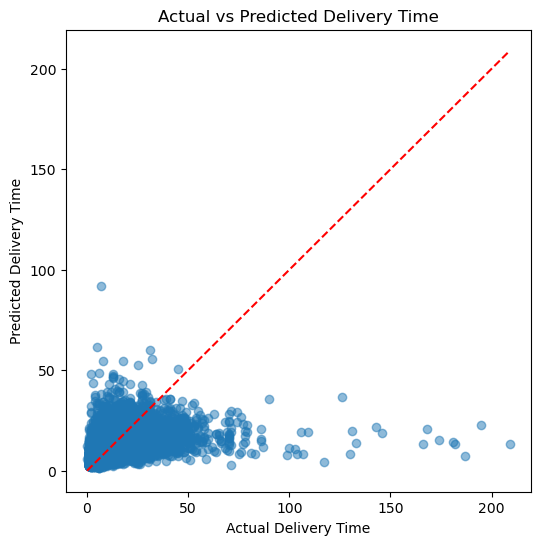

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.show()

## now i took 80 trees before it was 20 

In [169]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('clipper',
                                                                   OutlierClipper()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['customer_zip_code_prefix', 'total_order_value', 'total_order_items',
       'total_freight_value', 'total_payment_value',
       'total_payment_installments', 'total_payment_type'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['order_status', 'customer_state'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=80, n_jobs=-1,
                                       random_state=42))])

In [170]:
y_pred = model.predict(X_test)

In [171]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 5.63
MSE  : 85.04
RMSE : 9.22
R²   : 0.1510


## this mean that my preprocessing is worst beacuse adding 60 more tree also didn't make any impact on my model accuracy 